Embeddings : (2078, 32)
Labels     : (2078, 5)  (5 classes)
Train/Val/Test split: 1246 / 415 / 417
k=2  HL=0.2849  F1=0.3939  t=0.4s
k=3  HL=0.2873  F1=0.3594  t=0.4s
k=4  HL=0.2863  F1=0.3839  t=0.5s


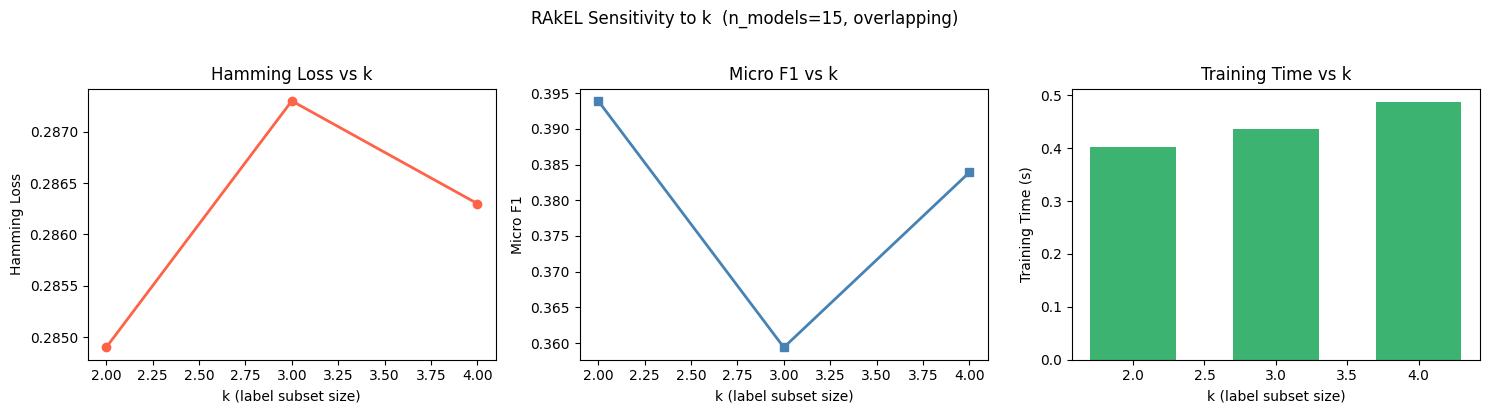

n_models=  2  HL=0.3118  F1=0.3187
n_models=  5  HL=0.2921  F1=0.3805
n_models= 10  HL=0.3012  F1=0.3843
n_models= 15  HL=0.2873  F1=0.3594
n_models= 20  HL=0.2796  F1=0.3670
n_models= 30  HL=0.2835  F1=0.3652
n_models= 40  HL=0.2796  F1=0.3778


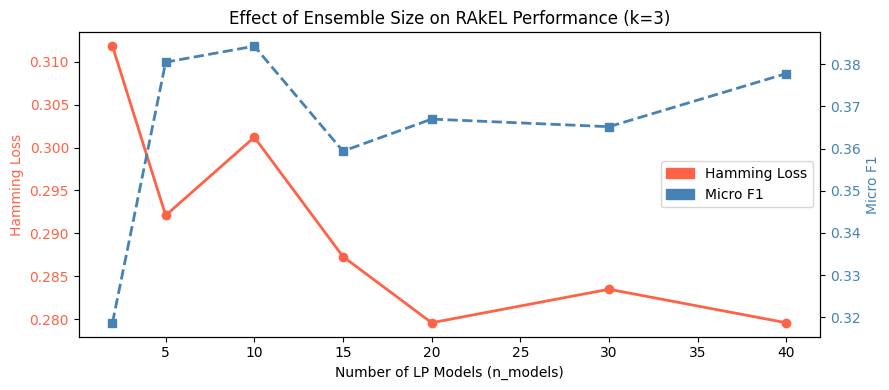

RAkEL + Decision Tree           MicroF1=0.3670  HL=0.2796  t=0.6s
RAkEL + SVM                     MicroF1=0.4231  HL=0.2590  t=1.0s
RAkEL + Logistic Regression     MicroF1=0.4354  HL=0.2600  t=0.8s


,Hamming Loss,Exact Match,Micro F1,Macro F1,Sample F1,Jaccard,Time (s)
Model,,,,,,,
RAkEL + Decision Tree,0.2796,0.2638,0.3670,0.3122,0.3368,0.3175,0.5790
RAkEL + SVM,0.2590,0.3381,0.4231,0.3441,0.4075,0.3893,1.0300
RAkEL + Logistic Regression,0.2600,0.3405,0.4354,0.3623,0.4255,0.4037,0.7580


In [86]:
# ============================================================
# RAkEL Analysis on GNN Embeddings — YEAST Dataset
# ============================================================
# Loads pre-computed GNN embeddings, then benchmarks RAkEL across:
#   1. Sensitivity to label subset size k
#   2. Effect of ensemble size (n_models)
#   3. Comparison of base classifiers
# ============================================================

import pickle
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from time import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

sys.path.insert(0, "./../MAIN/")
from applications import RAkEL
from train import evaluate_multilabel, per_class_metrics_from_scores

# ── Config ────────────────────────────────────────────────────────────────────
PKL_PATH   = "/work/gr-fe/bryan/data/SHCS/03_final/mogsage_gnn_embeddings_0.2.pkl"
K_DEFAULT  = 3          # label subset size used outside the k-sweep
N_MODELS_DEFAULT = 15   # ensemble size used outside the n_models-sweep
THRESHOLD  = 0.5
RANDOM_STATE = 42

# ── 1. Load embeddings ────────────────────────────────────────────────────────
with open(PKL_PATH, "rb") as f:
    blob = pickle.load(f)

H         = blob["embeddings"]          # (N, d)
train_idx = blob["train_idx"]
val_idx   = blob["val_idx"]
test_idx  = blob["test_idx"]
y         = blob["y"].astype(int)       # (N, C) multi-hot
n_labels  = y.shape[1]

print(f"Embeddings : {H.shape}")
print(f"Labels     : {y.shape}  ({n_labels} classes)")
print(f"Train/Val/Test split: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

# ── 2. Build train / test sets (train + val → fit, test → evaluate) ───────────
fit_idx = np.concatenate([train_idx, val_idx])
X_train, y_train = H[fit_idx],    y[fit_idx]
X_test,  y_test  = H[test_idx],   y[test_idx]

# ── Helper ────────────────────────────────────────────────────────────────────
def run_rakel(k, n_models, base_clf, X_tr=X_train, y_tr=y_train,
              X_te=X_test, y_te=y_test, mode="overlapping"):
    """Fit a RAkEL model and return (metrics_dict, elapsed_seconds)."""
    model = RAkEL(k=k, n_models=n_models, base_clf=base_clf,
                  mode=mode, threshold=THRESHOLD)
    t0 = time()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    elapsed = time() - t0
    metrics = evaluate_multilabel(y_te, y_pred)
    return metrics, elapsed, y_pred

# ── 3. Sweep k ────────────────────────────────────────────────────────────────
k_range = range(2, min(8, n_labels))
k_results = []

for k in k_range:
    m, t, _ = run_rakel(k, N_MODELS_DEFAULT,
                     DecisionTreeClassifier(random_state=RANDOM_STATE))
    k_results.append({"k": k, "Hamming Loss": m["Hamming Loss"],
                       "Micro F1": m["Micro F1"], "Time (s)": t})
    print(f"k={k}  HL={m['Hamming Loss']:.4f}  F1={m['Micro F1']:.4f}  t={t:.1f}s")

df_k = pd.DataFrame(k_results).set_index("k")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_k.index, df_k["Hamming Loss"], "o-", color="tomato",     lw=2)
axes[1].plot(df_k.index, df_k["Micro F1"],     "s-", color="steelblue",  lw=2)
axes[2].bar(df_k.index,  df_k["Time (s)"],          color="mediumseagreen", width=0.6)
for ax, ylabel, title in zip(
    axes,
    ["Hamming Loss", "Micro F1", "Training Time (s)"],
    ["Hamming Loss vs k", "Micro F1 vs k", "Training Time vs k"]
):
    ax.set_xlabel("k (label subset size)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
fig.suptitle(
    f"RAkEL Sensitivity to k  (n_models={N_MODELS_DEFAULT}, overlapping)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# ── 4. Sweep n_models ─────────────────────────────────────────────────────────
n_model_range = [2, 5, 10, 15, 20, 30, 40]
nm_results = []

for n_m in n_model_range:
    m, _, _ = run_rakel(K_DEFAULT, n_m,
                     DecisionTreeClassifier(random_state=RANDOM_STATE))
    nm_results.append({"n_models": n_m, "Hamming Loss": m["Hamming Loss"],
                        "Micro F1": m["Micro F1"]})
    print(f"n_models={n_m:3d}  HL={m['Hamming Loss']:.4f}  F1={m['Micro F1']:.4f}")

df_nm = pd.DataFrame(nm_results).set_index("n_models")

fig, ax1 = plt.subplots(figsize=(9, 4))
color1, color2 = "tomato", "steelblue"
ax1.plot(df_nm.index, df_nm["Hamming Loss"], "o-", color=color1, lw=2)
ax1.set_xlabel("Number of LP Models (n_models)")
ax1.set_ylabel("Hamming Loss", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(df_nm.index, df_nm["Micro F1"], "s--", color=color2, lw=2)
ax2.set_ylabel("Micro F1", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title(f"Effect of Ensemble Size on RAkEL Performance (k={K_DEFAULT})")
plt.legend(
    handles=[mpatches.Patch(color=c, label=l)
             for c, l in [(color1, "Hamming Loss"), (color2, "Micro F1")]],
    loc="center right"
)
plt.tight_layout()
plt.show()

# ── 5. Compare base classifiers ───────────────────────────────────────────────
base_clfs = {
    "Decision Tree"      : DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM"                : SVC(decision_function_shape="ovo",  random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=500, solver="lbfgs"),
}

clf_results = []
y_pred = []
for name, clf in base_clfs.items():
    m, t, y_pred_tmp = run_rakel(k=3, n_models=20, base_clf=clf)
    y_pred.append(y_pred_tmp)
    m["Model"]    = f"RAkEL + {name}"
    m["Time (s)"] = round(t, 3)
    clf_results.append(m)
    print(f"RAkEL + {name:<22s}  MicroF1={m['Micro F1']:.4f}  HL={m['Hamming Loss']:.4f}  t={t:.1f}s")

(
    pd.DataFrame(clf_results)
    .set_index("Model")
    .style
    .background_gradient(subset=["Micro F1", "Sample F1"], cmap="Greens")
    .background_gradient(subset=["Hamming Loss"],           cmap="Reds_r")
    .format(precision=4)
    .set_caption("RAkEL with Different Base Classifiers (k=7, n_models=50)")
)

In [87]:
out = per_class_metrics_from_scores(y_pred[2] , y_test)
print(out)

{'per_class': {'accuracy': array([0.75539568, 0.75059952, 0.80815348, 0.5971223 , 0.78896882]), 'f1_micro': array([0.4       , 0.36585366, 0.3220339 , 0.5862069 , 0.1372549 ]), 'f1_macro': array([0.62319277, 0.60531489, 0.60515103, 0.59684177, 0.50851816]), 'precision': array([0.39534884, 0.51724138, 0.48717949, 0.52654867, 0.25925926]), 'recall': array([0.4047619 , 0.28301887, 0.24050633, 0.66111111, 0.09333333]), 'support_pos': array([ 84, 106,  79, 180,  75])}, 'confusion': {'tp': array([ 34,  30,  19, 119,   7]), 'fp': array([ 52,  28,  20, 107,  20]), 'fn': array([50, 76, 60, 61, 68]), 'tn': array([281, 283, 318, 130, 322])}}


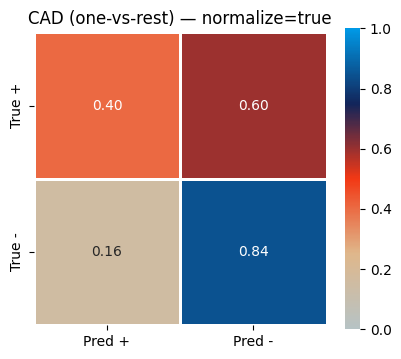

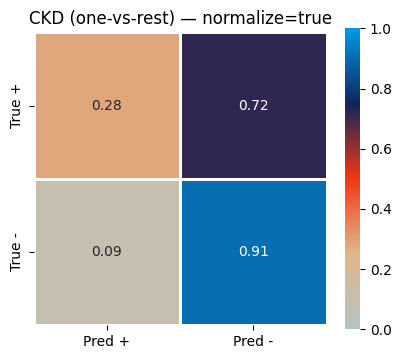

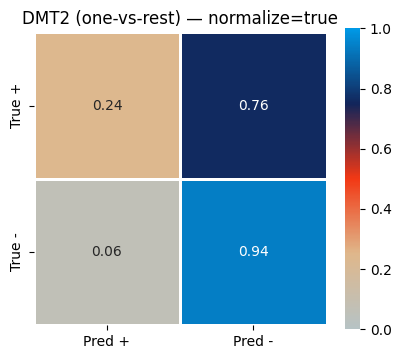

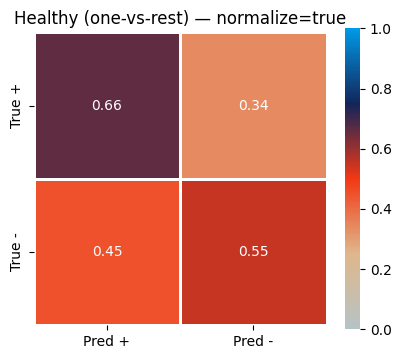

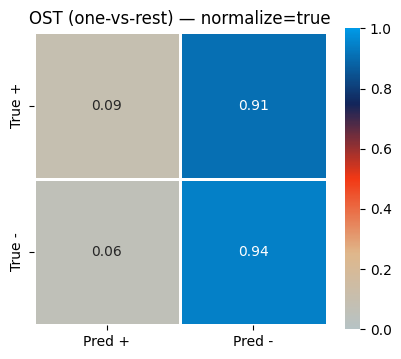

In [88]:
_ = plot_per_class_confusion_matrices(out , class_labels=blob['label_names'])

In [62]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_per_class_confusion_matrices(
    metrics_dict,
    class_labels=None,
    normalize="true",          # "true" | "pred" | "all" | None
    show_counts=False,         # if True, annotate "prop\n(count)"
    annotate_fmt=".2f",
    figsize_per_plot=(4.2, 3.6),
    cbar=True,
):
    """
    Plot one-vs-rest 2x2 confusion matrices per class as proportions,
    using the Wes Anderson 'Zissou' continuous colormap.

    Expects:
      metrics_dict['confusion'] with keys 'tp','fp','fn','tn' as arrays (n_classes,)
    """
    conf = metrics_dict["confusion"]
    tp = np.asarray(conf["tp"], dtype=float)
    fp = np.asarray(conf["fp"], dtype=float)
    fn = np.asarray(conf["fn"], dtype=float)
    tn = np.asarray(conf["tn"], dtype=float)

    n_classes = tp.shape[0]
    if class_labels is None:
        class_labels = [f"Class {i}" for i in range(n_classes)]
    if len(class_labels) != n_classes:
        raise ValueError(f"Expected {n_classes} class_labels, got {len(class_labels)}")

    # Wes Anderson palette via palettable: Zissou continuous colormap
    from palettable.wesanderson import Zissou_5_r as _Z
    cmap = _Z.mpl_colormap  # continuous matplotlib colormap

    figs = []
    for i, label in enumerate(class_labels):
        cm_counts = np.array([[tp[i], fn[i]],
                              [fp[i], tn[i]]], dtype=float)

        # ---- normalize to proportions ----
        if normalize is None:
            cm = cm_counts
        elif normalize == "true":
            denom = cm_counts.sum(axis=1, keepdims=True)
            cm = np.divide(cm_counts, denom, out=np.zeros_like(cm_counts), where=denom != 0)
        elif normalize == "pred":
            denom = cm_counts.sum(axis=0, keepdims=True)
            cm = np.divide(cm_counts, denom, out=np.zeros_like(cm_counts), where=denom != 0)
        elif normalize == "all":
            denom = cm_counts.sum()
            cm = cm_counts / denom if denom != 0 else np.zeros_like(cm_counts)
        else:
            raise ValueError('normalize must be one of: "true", "pred", "all", or None')

        # ---- annotations ----
        if show_counts and normalize is not None:
            ann = np.empty_like(cm, dtype=object)
            for r in range(2):
                for c in range(2):
                    ann[r, c] = f"{cm[r,c]:{annotate_fmt}}\n({int(cm_counts[r,c])})"
            annot = ann
            fmt = ""
        else:
            annot = True
            fmt = annotate_fmt if normalize is not None else "d"

        fig, ax = plt.subplots(figsize=figsize_per_plot)
        sns.heatmap(
            cm,
            ax=ax,
            annot=annot,
            fmt=fmt,
            cmap=cmap,
            cbar=cbar,
            vmin=0.0,
            vmax=1.0 if normalize is not None else None,
            square=True,
            linewidths=1,
            linecolor="white",
            xticklabels=["Pred +", "Pred -"],
            yticklabels=["True +", "True -"],
        )
        ax.set_title(f"{label} (one-vs-rest) — normalize={normalize}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        plt.tight_layout()
        figs.append(fig)

    return figs


In [ ]:
best_emb_distill = clf_results[2]
best_emb_distill['Model'] = 'GNN + Contrastive'
best_emb_distill['Time (s)'] = 120.00

#best_emb_nodistill = clf_results[1]
#best_emb_nodistill['Model'] = 'GNN Only'
best_emb_nodistill['Time (s)'] = 120.00

best_nn = {'Model': 'Neural Network',
 'Hamming Loss': 0.3736,
 'Exact Match': 0.1559,
 'Micro F1': 0.4892,
 'Macro F1': 0.4456,
 'Jaccard': 0.4092}

styler = (
    pd.DataFrame([best_emb_distill, best_emb_nodistill, best_nn])
      .set_index("Model")
      .style
      .background_gradient(subset=["Exact Match", "Micro F1", "Macro F1", "Jaccard"], cmap="Greens")
      .background_gradient(subset=["Hamming Loss"], cmap="Reds")
      .format(precision=4)
      .set_caption("RAkEL with Different Base Classifiers (k=7, n_models=50)")
)

html = styler.to_html()

from weasyprint import HTML
HTML(string=html).write_pdf("table.pdf")
